In [123]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,FunctionTransformer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,r2_score
import seaborn as sns
import matplotlib.pyplot as plt

In [124]:
df = pd.read_csv('train.csv')

x = df.drop(columns = ['SalePrice','Id'])
y = df['SalePrice']

In [125]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [126]:
print("Train Shape",x_train.shape)
print("Test Shape",x_test.shape)

Train Shape (1168, 79)
Test Shape (292, 79)


In [127]:
def create_new_feature(x):
    x = x.copy()
    cols = ['PoolQC','Alley','Fence','MiscFeature','MasVnrType','FireplaceQu','GarageType']
    for col in cols:
        if col in x.columns:
            clean_name = col.replace('Qu',"").replace('Feature','').replace('Misc','')
            x[f'Has_{clean_name}'] = x[col].notna().astype(int)
    return x

has_ft = FunctionTransformer(create_has_feature,validate=False)

print("Has_ Transformer created succesfully")

Has_ Transformer created succesfully


In [128]:
preprocessor = ColumnTransformer([
    ('has_fireplace',FunctionTransformer(lambda x: x['FireplaceQu'].notna().astype(int).values.reshape(-1,1),validate=False),['FireplaceQu']),
    ('has_garage',FunctionTransformer(lambda x: x['GarageType'].notna().astype(int).values.reshape(-1,1),validate = False),['GarageType']),
    ('num',SimpleImputer(strategy='median'),['LotFrontage','MasVnrArea','GarageYrBlt','YearBuilt','YearRemodAdd']),
    ('cat',Pipeline([
        ('imputer',SimpleImputer(strategy='most_frequent')),
        ('encoder',OneHotEncoder(handle_unknown='ignore',sparse_output=False,max_categories=8))
    ]),['Neighborhood','MSZoning','HouseStyle','BldgType','Exterior1st','KitchenQual'])
],remainder = 'drop')

x_train_clean = preprocessor.fit_transform(x_train)
print("Clean Shape:",x_train_clean.shape)
print("First 10 Values of first row:",x_train_clean[0][:10])

Clean Shape: (1168, 45)
First 10 Values of first row: [0.000e+00 1.000e+00 7.000e+01 0.000e+00 1.957e+03 1.957e+03 1.957e+03
 0.000e+00 0.000e+00 0.000e+00]


In [129]:
full_pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('model',RandomForestRegressor(n_estimators=100,random_state = 42))
])
full_pipeline.fit(x_train,y_train)
pred = full_pipeline.predict(x_test)

mae = mean_absolute_error(y_test,pred)
r2 = r2_score(y_test,pred)

print("Mean Absolute Error:",mae)
print("R2 Score:",r2)

Mean Absolute Error: 27004.66441495434
R2 Score: 0.7617455914878178


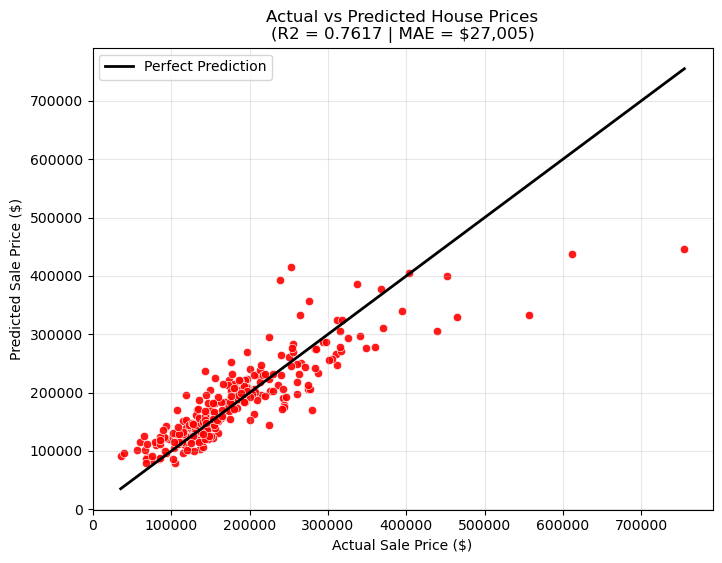

In [149]:
plt.figure(figsize = (8,6))
sns.scatterplot(x = y_test,y = y_pred,alpha = 0.9,color = 'red')
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'black',lw = 2,label = 'Perfect Prediction')
plt.xlabel("Actual Sale Price ($)")
plt.ylabel('Predicted Sale Price ($)')
plt.title('Actual vs Predicted House Prices\n(R2 = {:.4f} | MAE = ${:,.0f})'.format(r2,mae))
plt.legend()
plt.grid(True,alpha = 0.3)
plt.show()

### Summary:
- I worked on the famous House Prices dataset (1460 rows, 81 columns) which had many missing values. Instead of simply dropping columns with high missing values (like PoolQC, Alley, Fence), I created smart binary features such as Has_Pool, Has_Fireplace, and Has_Garage to keep important information.
- I used scikit-learn Pipeline + ColumnTransformer to automate the preprocessing (handling missing values, creating features, and encoding categorical variables) while preventing data leakage by doing train-test split first. Finally, I trained a RandomForestRegressor model which achieved R² = 0.76 and MAE ≈ $27,000.
- Visualization: Scatter plot of Actual vs Predicted house prices.
- Tools used: pandas, scikit-learn (Pipeline, ColumnTransformer), Seaborn, Matplotlib